## DOMAIN: Automobile

#### PROJECT OBJECTIVE: To understand K-means Clustering by applying on the Car Dataset to segment the cars into various categories.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix,classification_report,silhouette_score,silhouette_samples
from sklearn.decomposition import PCA


from scipy.stats import zscore 
from scipy.spatial.distance import cdist


import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

### 1. Data Understanding & Exploration

**A. Read ‘Car name.csv’ as a DataFrame and assign it to a variable.**

In [2]:
car_name=pd.read_csv("Part1+-+Car+name.csv")
car_name.head()

,car_name
0,chevrolet chevelle malibu
1,buick skylark 320
2,plymouth satellite
3,amc rebel sst
4,ford torino


In [3]:
car_name.shape

(398, 1)

**B. Read ‘Car-Attributes.json as a DataFrame and assign it to a variable.**

In [4]:
car_attributes=pd.read_json("Part1+-+Car-Attributes.json")
car_attributes.head()

,mpg,cyl,disp,hp,wt,acc,yr,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1


In [5]:
car_attributes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     398 non-null    float64
 1   cyl     398 non-null    int64  
 2   disp    398 non-null    float64
 3   hp      398 non-null    object 
 4   wt      398 non-null    int64  
 5   acc     398 non-null    float64
 6   yr      398 non-null    int64  
 7   origin  398 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 25.0+ KB


In [6]:
car_attributes.shape

(398, 8)

**C. Merge both the DataFrames together to form a single DataFrame**

In [7]:
car=car_name.join(car_attributes,how="left")

In [8]:
car

,car_name,mpg,cyl,disp,hp,wt,acc,yr,origin
0,chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
1,buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
2,plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
3,amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
4,ford torino,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...,...
393,ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1
394,vw pickup,44.0,4,97.0,52,2130,24.6,82,2
395,dodge rampage,32.0,4,135.0,84,2295,11.6,82,1
396,ford ranger,28.0,4,120.0,79,2625,18.6,82,1


In [9]:
car.shape

(398, 9)

**D. Print 5 point summary of the numerical features and share insights.**

In [10]:
car.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
cyl,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
disp,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
wt,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acc,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
yr,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
origin,398.0,1.572864,0.802055,1.0,1.000,1.0,2.000,3.0


Insights from the 5 point summary:
- For the attributes mpg, acc and yr, Mean and median are almost the same and it is also observed that the difference between the 75th percentile and the max value is not very large hence we can interpret that the corresponding distributions could be symmetric
- wt and disp have a slightly right skewed distributions since the mean > median
- Half of the cars in the dataset has either 3 or 4 cylinders with most of it having 4
- disp attribute is likely to have outliers because the max value is very much higher than the 75% values in the dataset

### 2. Data Preparation & Analysis

**A. Check and print feature-wise percentage of missing values present in the data and impute with the best suitable approach.**

In [11]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   car_name  398 non-null    object 
 1   mpg       398 non-null    float64
 2   cyl       398 non-null    int64  
 3   disp      398 non-null    float64
 4   hp        398 non-null    object 
 5   wt        398 non-null    int64  
 6   acc       398 non-null    float64
 7   yr        398 non-null    int64  
 8   origin    398 non-null    int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [12]:
for i in car.columns:
    
    print("The percentage of null values in the column ",i,"is: ",car[i].isnull().sum()/car.shape[0])

The percentage of null values in the column  car_name is:  0.0
The percentage of null values in the column  mpg is:  0.0
The percentage of null values in the column  cyl is:  0.0
The percentage of null values in the column  disp is:  0.0
The percentage of null values in the column  hp is:  0.0
The percentage of null values in the column  wt is:  0.0
The percentage of null values in the column  acc is:  0.0
The percentage of null values in the column  yr is:  0.0
The percentage of null values in the column  origin is:  0.0


None of the columns in the dataset has null values. This can also be shown using the info()

In [13]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   car_name  398 non-null    object 
 1   mpg       398 non-null    float64
 2   cyl       398 non-null    int64  
 3   disp      398 non-null    float64
 4   hp        398 non-null    object 
 5   wt        398 non-null    int64  
 6   acc       398 non-null    float64
 7   yr        398 non-null    int64  
 8   origin    398 non-null    int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


**B. Check for duplicate values in the data and impute with the best suitable approach**

In [14]:
car.duplicated().sum()

0

There are no duplicated rows in the dataset

**C. Plot a pairplot for all features**

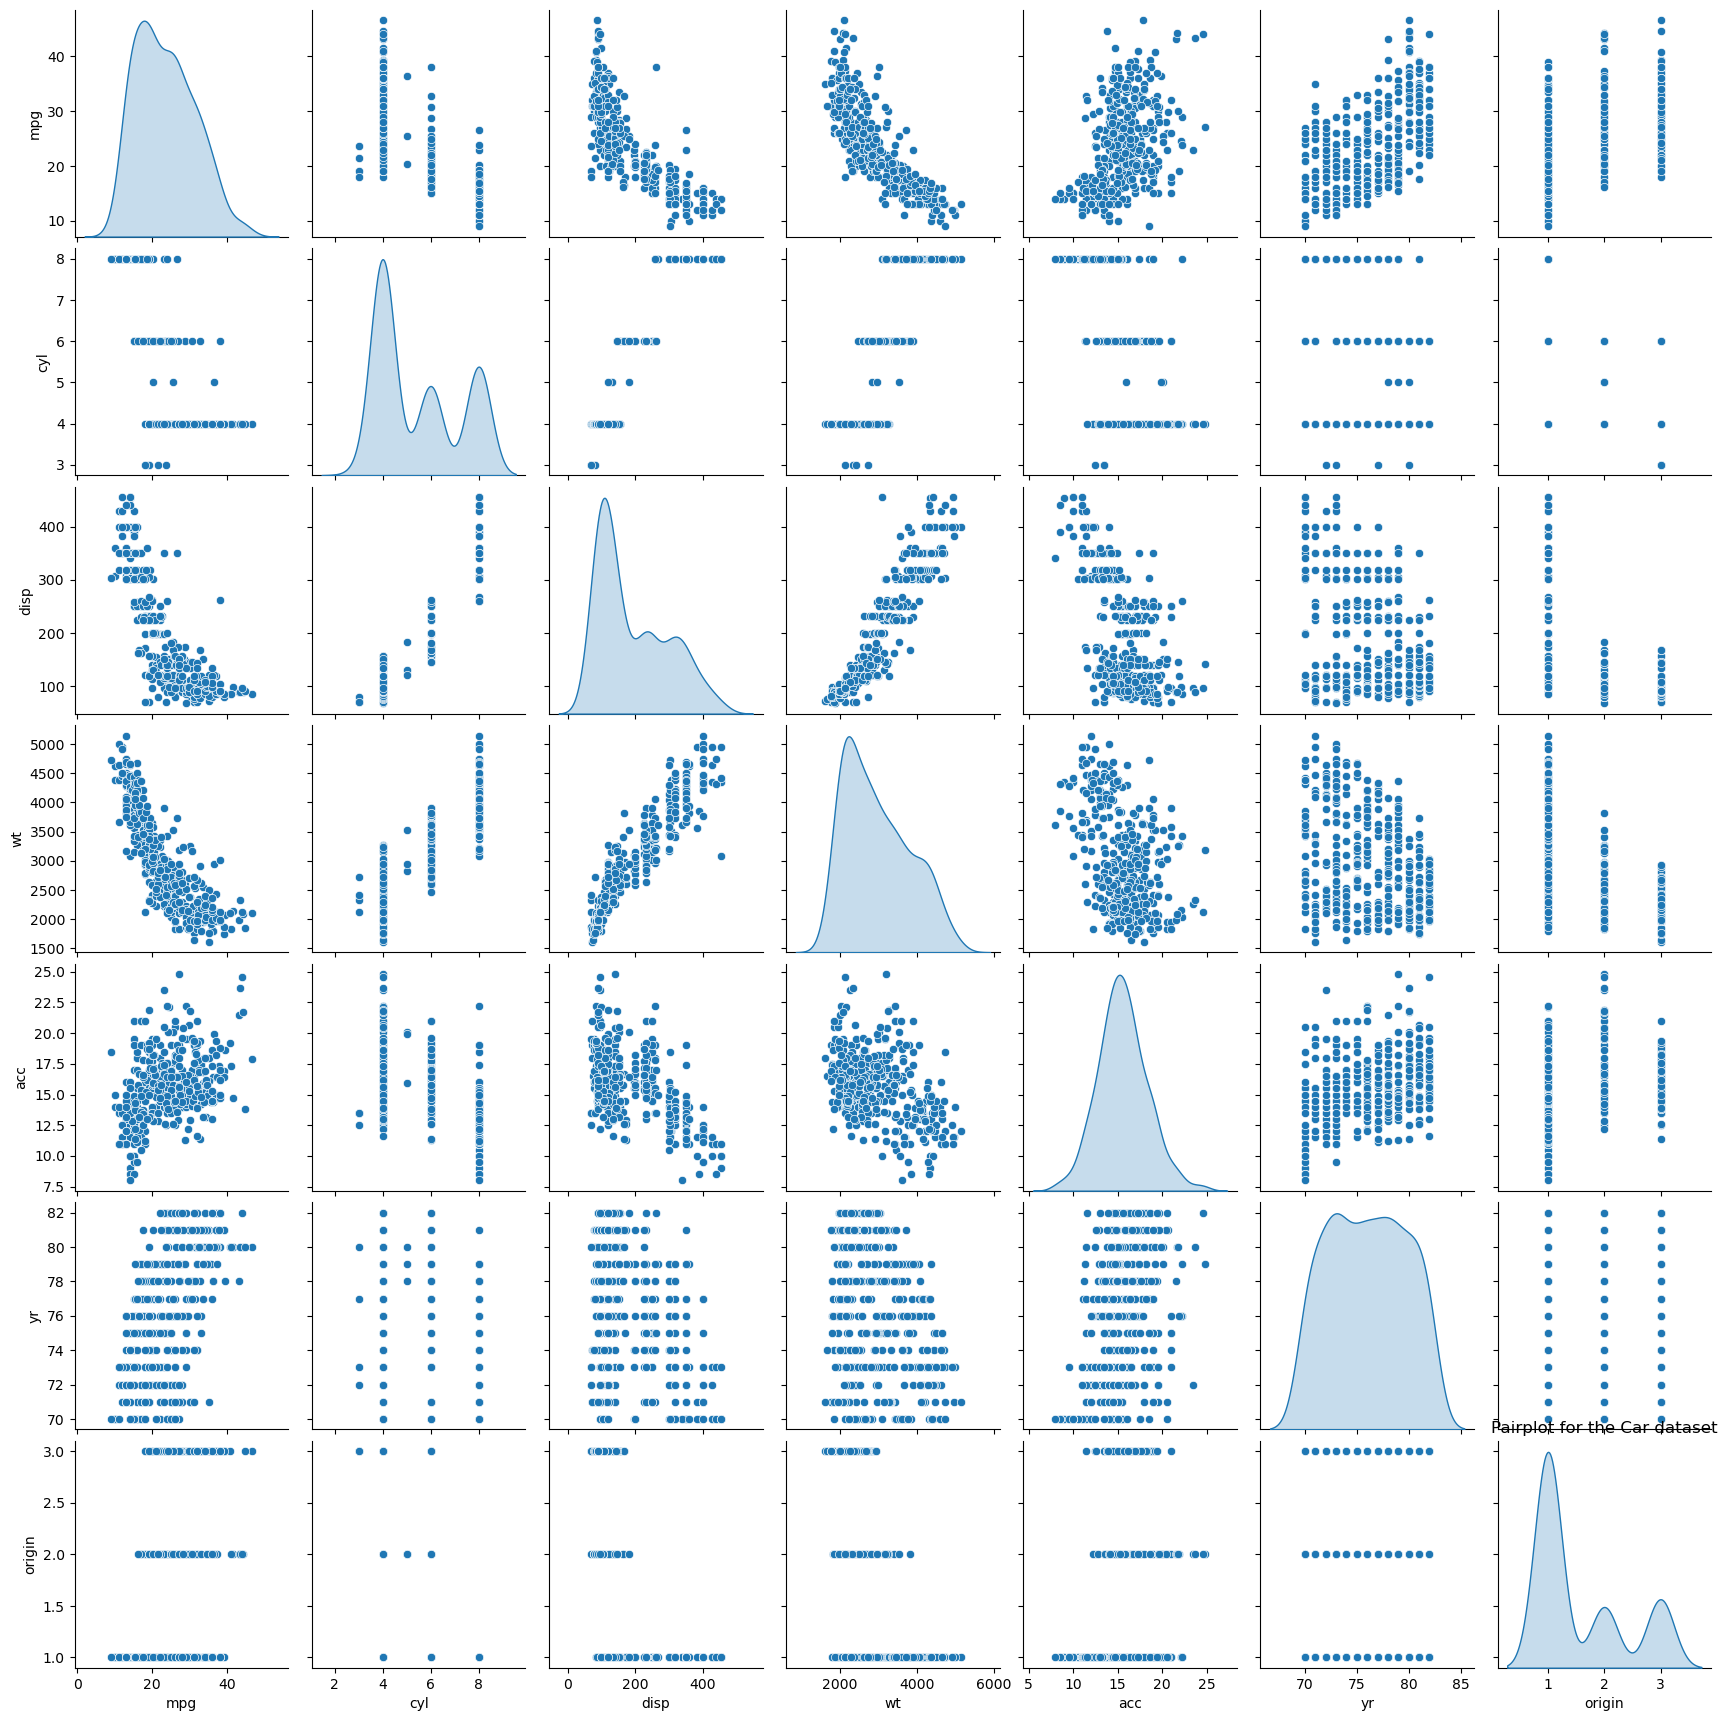

In [15]:
sns.pairplot(car,diag_kind="kde")
plt.title("Pairplot for the Car dataset")
plt.show();

Insights from the pairplot:
- mpg is having a negative correlation between disp and wt 
- mpg and disp is also having a slight negative correlation but it is not very prominent 
- disp and wt has a positive correlation
- wt and acc does not show any correlation 
- acc has a symmetric normal distribution
- mpg, disp and wt are also normally distributed but the distributions are right skewed

**D. Visualize a scatterplot for ‘wt’ and ‘disp’. Datapoints should be distinguishable by ‘cyl’.**

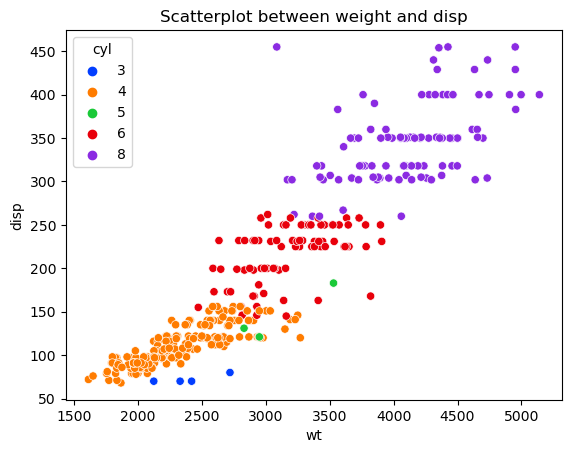

In [16]:
sns.scatterplot(data=car,x="wt",y="disp",hue="cyl",palette="bright")
plt.title("Scatterplot between weight and disp")
plt.show();

**E. Share insights for Q2.d.**

Insights from the scatterplot between wt and disp:
- wt and disp has a strong positive correlation, as the weight increases it can be seen that the disp also tends to increase
- vehicles with less weight has less number of cylinders and hence the disp is also less
- vehicles with the maximum weight has the maximum number of cylinders and hence the disp is also high for the same

**F. Visualize a scatterplot for ‘wt’ and ’mpg’. Datapoints should be distinguishable by ‘cyl’.**

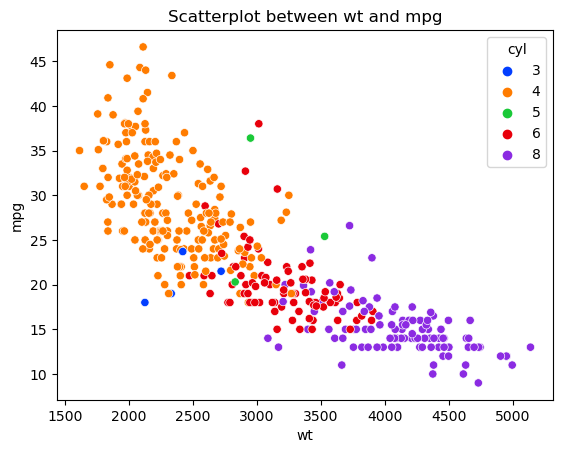

In [17]:
sns.scatterplot(car,x="wt",y="mpg",hue="cyl",palette="bright")
plt.title("Scatterplot between wt and mpg")
plt.show()

**G. Share insights for Q2.f.**

Insights from the scatterplot between wt and mpg:
- mpg and wt are having a negative correlation since from the scatter plot we can see that as the weight increases miles per gallon(mpg) tends to decrease
- As the number of cylinders increases, the weight increases and as the weight increases it is observed from the graph that the mpg decreases
- vehicles with the less number of cylinders have the maximum mileage

**H. Check for unexpected values in all the features and datapoints with such values.**

In [18]:
#Displaying the unique values in the attributes to find if there are any values that needs to be imputed.

for i in car.columns:
    print("Values in column: ",i)
    print(car[i].unique())
    print("__"*30)

Values in column:  car_name
['chevrolet chevelle malibu' 'buick skylark 320' 'plymouth satellite'
 'amc rebel sst' 'ford torino' 'ford galaxie 500' 'chevrolet impala'
 'plymouth fury iii' 'pontiac catalina' 'amc ambassador dpl'
 'dodge challenger se' "plymouth 'cuda 340" 'chevrolet monte carlo'
 'buick estate wagon (sw)' 'toyota corona mark ii' 'plymouth duster'
 'amc hornet' 'ford maverick' 'datsun pl510'
 'volkswagen 1131 deluxe sedan' 'peugeot 504' 'audi 100 ls' 'saab 99e'
 'bmw 2002' 'amc gremlin' 'ford f250' 'chevy c20' 'dodge d200' 'hi 1200d'
 'chevrolet vega 2300' 'toyota corona' 'ford pinto'
 'plymouth satellite custom' 'ford torino 500' 'amc matador'
 'pontiac catalina brougham' 'dodge monaco (sw)'
 'ford country squire (sw)' 'pontiac safari (sw)'
 'amc hornet sportabout (sw)' 'chevrolet vega (sw)' 'pontiac firebird'
 'ford mustang' 'mercury capri 2000' 'opel 1900' 'peugeot 304' 'fiat 124b'
 'toyota corolla 1200' 'datsun 1200' 'volkswagen model 111'
 'plymouth cricket' 'toyota

In [19]:
#In the column "hp" there is a special character "?". Lets impute the "?" with the median in the column
car["hp"]=car["hp"].replace("?",0)

In [20]:
car["hp"]=car["hp"].astype(int)

"hp" is a continous column and hence we can replace the special characters with the mean

In [21]:
car["hp"].replace(0,car["hp"].mean())

0      130.0
1      165.0
2      150.0
3      150.0
4      140.0
       ...  
393     86.0
394     52.0
395     84.0
396     79.0
397     82.0
Name: hp, Length: 398, dtype: float64

### 3. Clustering

**A. Apply K-Means clustering for 2 to 10 clusters.**

In [22]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   car_name  398 non-null    object 
 1   mpg       398 non-null    float64
 2   cyl       398 non-null    int64  
 3   disp      398 non-null    float64
 4   hp        398 non-null    int32  
 5   wt        398 non-null    int64  
 6   acc       398 non-null    float64
 7   yr        398 non-null    int64  
 8   origin    398 non-null    int64  
dtypes: float64(3), int32(1), int64(4), object(1)
memory usage: 26.6+ KB


car name is unique for each column so we can drop the column

In [23]:
car.drop("car_name",axis=1,inplace=True)

In [24]:
car.columns

Index(['mpg', 'cyl', 'disp', 'hp', 'wt', 'acc', 'yr', 'origin'], dtype='object')

Before applying any distance based algorithm, the dataset needs to be scaled.
Scaling the dataset Zscore and let us understand if there is any difference

In [25]:
Stdscaler=StandardScaler()
Stdscaler.fit(car)

StandardScaler()

In [26]:
car_zscaled=car.apply(zscore)

In [27]:
wcss=[]
for k in np.arange(2,11):
    Model=KMeans(k)
    Model.fit(car_zscaled)
    wcss.append(sum(np.min(cdist(Model.cluster_centers_,car_zscaled,metric="euclidean"),axis=0))/car_zscaled.shape[0])

wcss has the within cluster sum of square distances <br>

**B. Plot a visual and find elbow point**

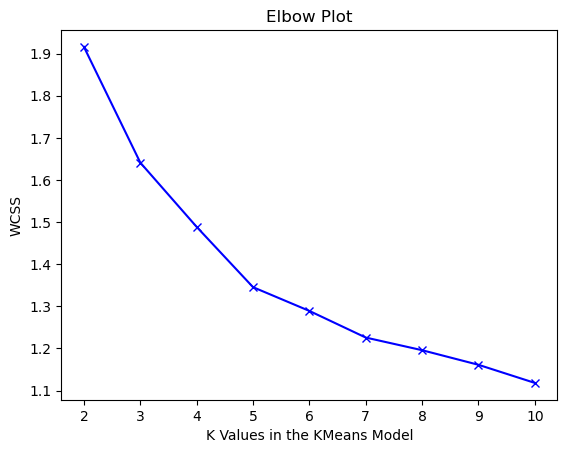

In [28]:
plt.plot(np.arange(2,11),wcss,"-bx")
plt.title("Elbow Plot")
plt.xlabel("K Values in the KMeans Model")
plt.ylabel("WCSS")
plt.show();

**C. On the above visual, highlight which are the possible Elbow points.**

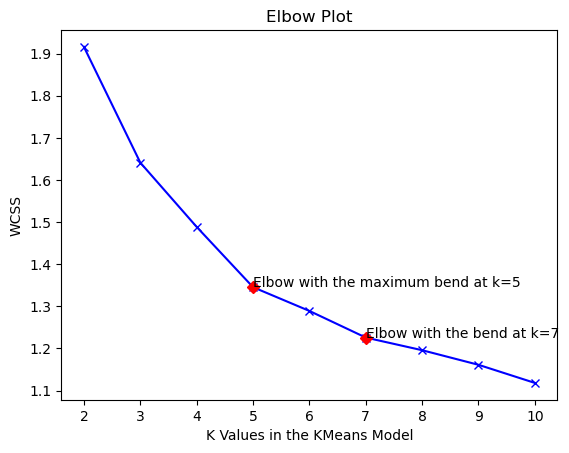

In [29]:
plt.plot(np.arange(2,11),wcss,"-bx")
plt.plot(5,wcss[3],c='red', marker='D')
plt.annotate("Elbow with the maximum bend at k=5",(5,wcss[3]))
plt.plot(7,wcss[5],c='red', marker='D')
plt.annotate("Elbow with the bend at k=7",(7,wcss[5]))
plt.title("Elbow Plot")
plt.xlabel("K Values in the KMeans Model")
plt.ylabel("WCSS")
plt.show();

**D. Train a K-means clustering model once again on the optimal number of clusters.**

In [30]:
# From the above Elbow plot we can say that the maximum bend is at K=5
#building a clustering model using K-Means clustering with K=5

KModel=KMeans(5,random_state=1)
KModel.fit(car_zscaled)

KMeans(n_clusters=5, random_state=1)

In [31]:
labels_1=KModel.labels_

In [32]:

cluster=pd.DataFrame(KModel.cluster_centers_,columns=car.columns,index=["Cluster 0","Cluster 1","Cluster 2","Cluster 3","Cluster 4"])
print("Cluster centers are as below ")
cluster

Cluster centers are as below 


,mpg,cyl,disp,hp,wt,acc,yr,origin
Cluster 0,-0.564892,0.451742,0.384281,-0.053857,0.387993,0.386319,-0.082954,-0.668909
Cluster 1,-1.163797,1.498191,1.503923,1.479382,1.404098,-1.086149,-0.688324,-0.715145
Cluster 2,0.675937,-0.742109,-0.584400,-0.567391,-0.480763,0.356240,0.991501,-0.621983
Cluster 3,1.360839,-0.807268,-0.901663,-0.810979,-0.963144,0.423579,0.922458,1.486835
Cluster 4,0.141488,-0.828291,-0.814535,-0.455879,-0.736371,0.195719,-0.731260,0.666976


**E. Add a new feature in the DataFrame which will have labels based upon cluster value.**

In [33]:
car_zscaled["Cluster"]=KModel.predict(car_zscaled)

In [34]:
car_zscaled

,mpg,cyl,disp,hp,wt,acc,yr,origin,Cluster
0,-0.706439,1.498191,1.090604,0.673950,0.630870,-1.295498,-1.627426,-0.715145,1
1,-1.090751,1.498191,1.503514,1.544187,0.854333,-1.477038,-1.627426,-0.715145,1
2,-0.706439,1.498191,1.196232,1.171228,0.550470,-1.658577,-1.627426,-0.715145,1
3,-0.962647,1.498191,1.061796,1.171228,0.546923,-1.295498,-1.627426,-0.715145,1
4,-0.834543,1.498191,1.042591,0.922589,0.565841,-1.840117,-1.627426,-0.715145,1
...,...,...,...,...,...,...,...,...,...
393,0.446497,-0.856321,-0.513026,-0.420063,-0.213324,0.011586,1.621983,-0.715145,2
394,2.624265,-0.856321,-0.925936,-1.265436,-0.993671,3.279296,1.621983,0.533222,3
395,1.087017,-0.856321,-0.561039,-0.469791,-0.798585,-1.440730,1.621983,-0.715145,2
396,0.574601,-0.856321,-0.705077,-0.594110,-0.408411,1.100822,1.621983,-0.715145,2


**Cluster frequency**

In [35]:
car_zscaled["Cluster"].value_counts().sort_index()

0    81
1    94
2    67
3    72
4    84
Name: Cluster, dtype: int64

**Cluster Profiling**

In [36]:
car["Cluster"]=car_zscaled["Cluster"]

In [37]:
car.head()

,mpg,cyl,disp,hp,wt,acc,yr,origin,Cluster
0,18.0,8,307.0,130,3504,12.0,70,1,1
1,15.0,8,350.0,165,3693,11.5,70,1,1
2,18.0,8,318.0,150,3436,11.0,70,1,1
3,16.0,8,304.0,150,3433,12.0,70,1,1
4,17.0,8,302.0,140,3449,10.5,70,1,1


In [38]:
car_zscaled.groupby("Cluster").mean()

,mpg,cyl,disp,hp,wt,acc,yr,origin
Cluster,,,,,,,,
0,-0.564892,0.451742,0.384281,-0.053857,0.387993,0.386319,-0.082954,-0.668909
1,-1.163797,1.498191,1.503923,1.479382,1.404098,-1.086149,-0.688324,-0.715145
2,0.675937,-0.742109,-0.584400,-0.567391,-0.480763,0.356240,0.991501,-0.621983
3,1.360839,-0.807268,-0.901663,-0.810979,-0.963144,0.423579,0.922458,1.486835
4,0.141488,-0.828291,-0.814535,-0.455879,-0.736371,0.195719,-0.731260,0.666976


In [39]:
car.groupby("Cluster").mean()

,mpg,cyl,disp,hp,wt,acc,yr,origin
Cluster,,,,,,,,
0,19.104938,6.222222,233.444444,100.728395,3298.580247,16.632099,75.703704,1.037037
1,14.429787,8.000000,350.042553,162.393617,4157.978723,12.576596,73.468085,1.000000
2,28.791045,4.194030,132.567164,80.074627,2563.805970,16.549254,79.671642,1.074627
3,34.137500,4.083333,99.527778,70.277778,2155.819444,16.734722,79.416667,2.763889
4,24.619048,4.047619,108.601190,84.559524,2347.619048,16.107143,73.309524,2.107143


In [40]:
#Let us apply number of clusters =7 

KModel2=KMeans(7,random_state=1)
KModel2.fit(car_zscaled)


KMeans(n_clusters=7, random_state=1)

In [41]:
labels_2=KModel2.labels_

In [42]:
#Silhoutte score computation with number of clusters =5 and 7
score_5clusters=silhouette_score(car_zscaled,labels_1)
score_7clusters=silhouette_score(car_zscaled,labels_2)

In [43]:
print("silhouette score with 5 clusters is ",score_5clusters)
print("silhouette score with 7 clusters is ",score_7clusters)

silhouette score with 5 clusters is  0.4020554242045989
silhouette score with 7 clusters is  0.31615444373372587


We can understand that silhouette score is better with 5 clusters than with 7 and hence we can conclude that number of clusters = 5 is the optimum clusters

**F. Plot a visual and color the datapoints based upon clusters.**

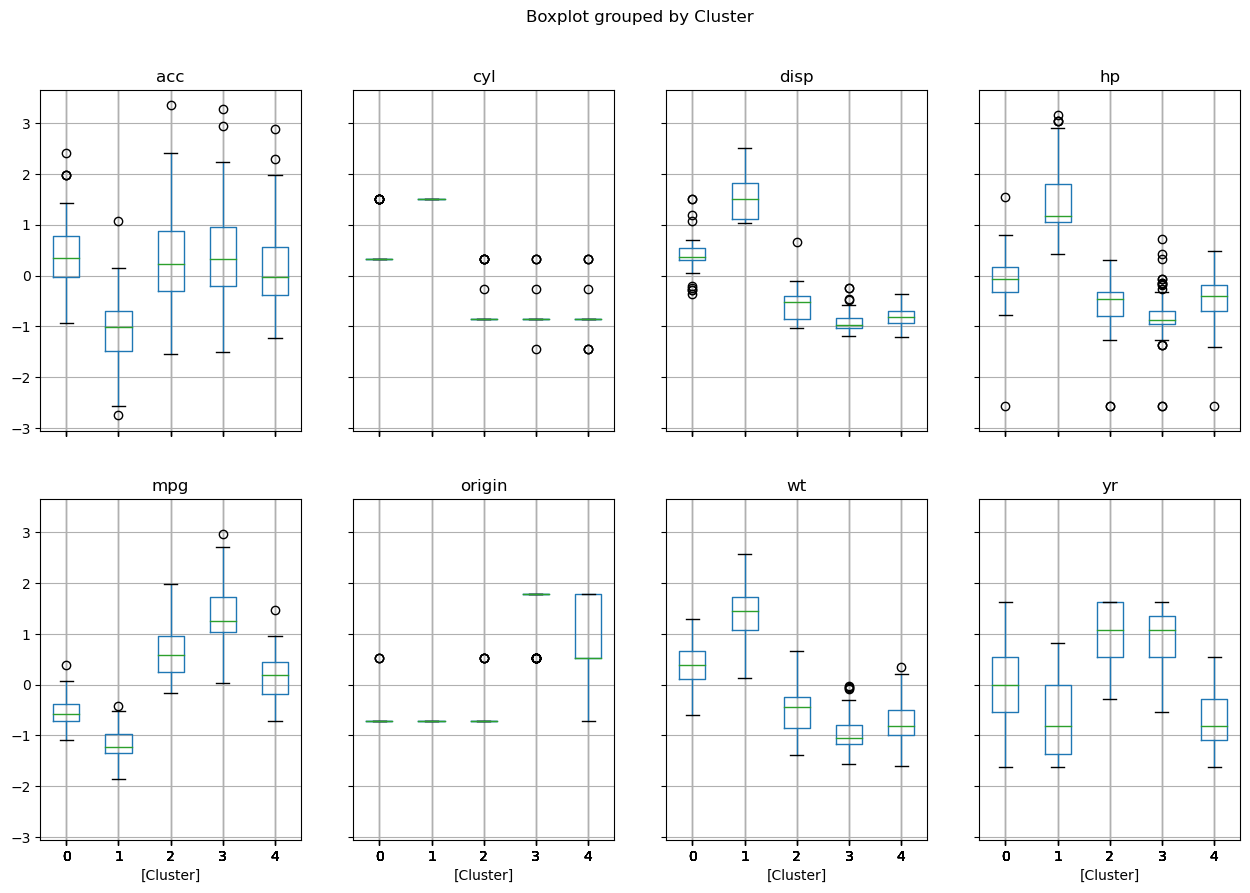

In [44]:
car_zscaled.boxplot(by="Cluster",layout=(2,4),figsize=(15,10))
plt.show();

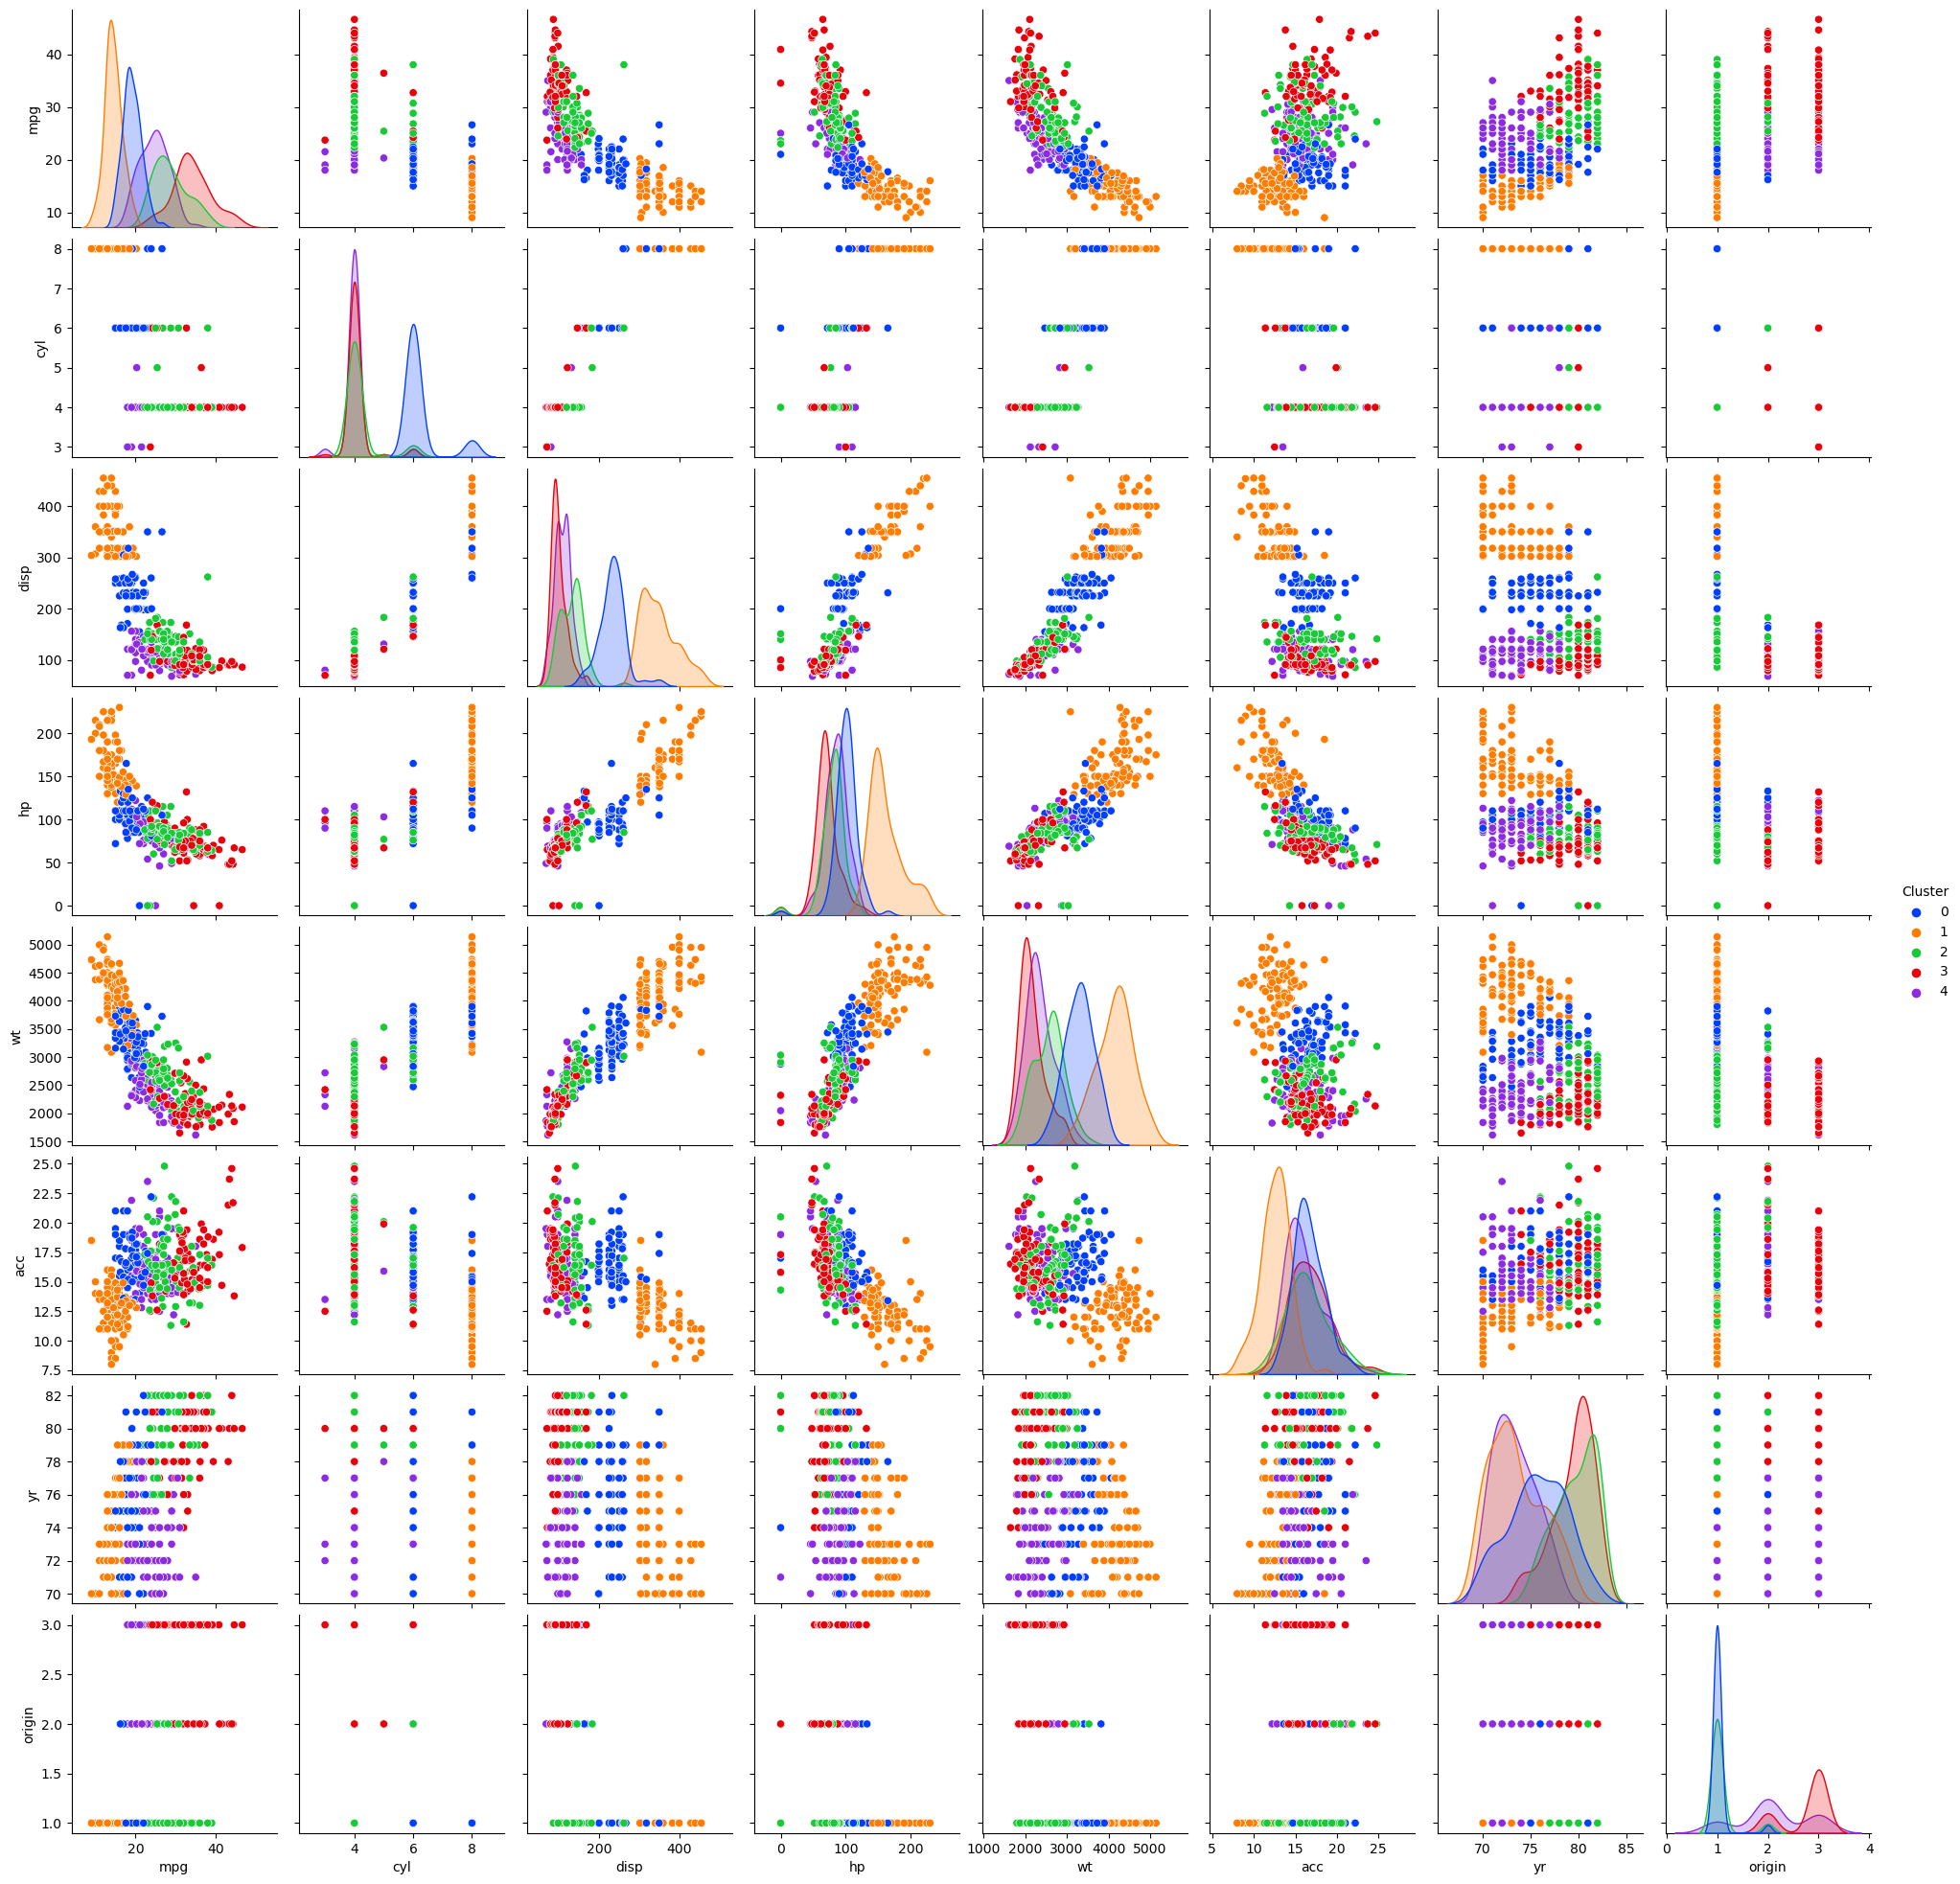

In [45]:
sns.pairplot(car,hue="Cluster",palette='bright')
plt.show();

**G. Pass a new DataPoint and predict which cluster it belongs to.**

In [46]:
car.columns

Index(['mpg', 'cyl', 'disp', 'hp', 'wt', 'acc', 'yr', 'origin', 'Cluster'], dtype='object')

In [47]:
#Creating a new dataframe with values close to the mean of cluster 2
#With scaled data
Sample_new1=pd.DataFrame.from_dict({'mpg':[0.14],'cyl':[-0.83], 'disp':[-0.81], 'hp':[-0.46], 'wt':[-0.74], 'acc':[0.2], 'yr':[-0.73], 'origin':[0.67]})

In [48]:
Sample_new1["Cluster"]=KModel.predict(Sample_new1)
Sample_new1

,mpg,cyl,disp,hp,wt,acc,yr,origin,Cluster
0,0.14,-0.83,-0.81,-0.46,-0.74,0.2,-0.73,0.67,4


The model has correctly predicted the provided dataframe to belong to cluster 2

In [49]:
#creating a new dataframe  with values close to the mean of cluster 4
#with datapoint that is not scaled
Sample_new2=pd.DataFrame.from_dict({'mpg':[19],'cyl':[6], 'disp':[233], 'hp':[100], 'wt':[3298], 'acc':[16], 'yr':[75], 'origin':[1]})

In [50]:
Sample_new2

,mpg,cyl,disp,hp,wt,acc,yr,origin
0,19,6,233,100,3298,16,75,1


In [51]:
sample=pd.DataFrame(Stdscaler.transform(Sample_new2),columns=['mpg', 'cyl', 'disp', 'hp', 'wt', 'acc', 'yr', 'origin'])

In [52]:
sample

,mpg,cyl,disp,hp,wt,acc,yr,origin
0,-0.578335,0.320935,0.380013,-0.071968,0.387307,0.156817,-0.273506,-0.715145


In [53]:
sample["cluster"]=KModel.predict(sample)

In [54]:
sample

,mpg,cyl,disp,hp,wt,acc,yr,origin,cluster
0,-0.578335,0.320935,0.380013,-0.071968,0.387307,0.156817,-0.273506,-0.715145,0


The model has correctly predicted the provided dataframe to belong to cluster 4

## DOMAIN: Automobile

#### PROJECT OBJECTIVE: Apply dimensionality reduction technique – PCA and train a model and compare relative results.**

### 1. Data Understanding & Cleaning

**A. Read ‘vehicle.csv’ and save as DataFrame.**

In [55]:
vehicle=pd.read_csv("vehicle.csv")

In [56]:
vehicle.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [57]:
vehicle.shape

(846, 19)

**B. Check percentage of missing values and impute with correct approach.**

In [58]:
vehicle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   compactness                  846 non-null    int64  
 1   circularity                  841 non-null    float64
 2   distance_circularity         842 non-null    float64
 3   radius_ratio                 840 non-null    float64
 4   pr.axis_aspect_ratio         844 non-null    float64
 5   max.length_aspect_ratio      846 non-null    int64  
 6   scatter_ratio                845 non-null    float64
 7   elongatedness                845 non-null    float64
 8   pr.axis_rectangularity       843 non-null    float64
 9   max.length_rectangularity    846 non-null    int64  
 10  scaled_variance              843 non-null    float64
 11  scaled_variance.1            844 non-null    float64
 12  scaled_radius_of_gyration    844 non-null    float64
 13  scaled_radius_of_gyr

In [59]:
#Finding the % of missing values
for i in vehicle.columns:
    print("% of missing values in column: ",i,"is ",round((vehicle[i].isnull().sum()/vehicle.shape[0])*100,2))

% of missing values in column:  compactness is  0.0
% of missing values in column:  circularity is  0.59
% of missing values in column:  distance_circularity is  0.47
% of missing values in column:  radius_ratio is  0.71
% of missing values in column:  pr.axis_aspect_ratio is  0.24
% of missing values in column:  max.length_aspect_ratio is  0.0
% of missing values in column:  scatter_ratio is  0.12
% of missing values in column:  elongatedness is  0.12
% of missing values in column:  pr.axis_rectangularity is  0.35
% of missing values in column:  max.length_rectangularity is  0.0
% of missing values in column:  scaled_variance is  0.35
% of missing values in column:  scaled_variance.1 is  0.24
% of missing values in column:  scaled_radius_of_gyration is  0.24
% of missing values in column:  scaled_radius_of_gyration.1 is  0.47
% of missing values in column:  skewness_about is  0.71
% of missing values in column:  skewness_about.1 is  0.12
% of missing values in column:  skewness_about.

In [60]:
#All the columns that are having null values are having continuous values and hence we can impute with the mean
for i in vehicle.columns:
    if round((vehicle[i].isnull().sum()/vehicle.shape[0])*100,2)!=0.0:
        vehicle[i].fillna(vehicle[i].mean(),inplace=True)

In [61]:
vehicle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   compactness                  846 non-null    int64  
 1   circularity                  846 non-null    float64
 2   distance_circularity         846 non-null    float64
 3   radius_ratio                 846 non-null    float64
 4   pr.axis_aspect_ratio         846 non-null    float64
 5   max.length_aspect_ratio      846 non-null    int64  
 6   scatter_ratio                846 non-null    float64
 7   elongatedness                846 non-null    float64
 8   pr.axis_rectangularity       846 non-null    float64
 9   max.length_rectangularity    846 non-null    int64  
 10  scaled_variance              846 non-null    float64
 11  scaled_variance.1            846 non-null    float64
 12  scaled_radius_of_gyration    846 non-null    float64
 13  scaled_radius_of_gyr

**C. Visualize a Pie-chart and print percentage of values for variable ‘class’.**

In [62]:
vehicle["class"]

0      van
1      van
2      car
3      van
4      bus
      ... 
841    car
842    van
843    car
844    car
845    van
Name: class, Length: 846, dtype: object

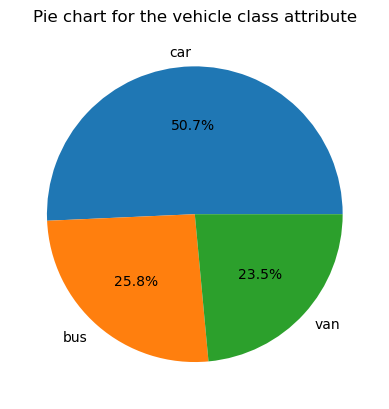

In [63]:
plt.pie(vehicle["class"].value_counts(),labels=vehicle["class"].value_counts().index,autopct='%.1f%%')
plt.title("Pie chart for the vehicle class attribute")
plt.show();

Insights from the piechart:
- Bus and Van classes are almost equally distributed
- half the dataset consists of car dataset
- dataset is not balanced

**D. Check for duplicate rows in the data and impute with correct approach.**

In [64]:
vehicle.duplicated().sum()

0

There are no duplicated rows in the dataset

### 2. Data Preparation

**A. Split data into X and Y.**

In [65]:
X=vehicle.drop("class",axis=1,inplace=False)
y=vehicle.loc[:,"class"]

In [66]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=1,stratify=y)

Splitting into train and test with 25% of the data considered as testing/validating data and 75% as the training data

**B. Standardize the Data.**

In [67]:
#X_train_Zscaled=X_train.apply(zscore)
#X_test_Zscaled=X_test.apply(zscore)
X_scaled=X.apply(zscore)

### 3. Model Building

**A. Train a base Classification model using SVM.**

In [68]:
Model1_svm=SVC(random_state=1)

In [69]:
#Model1_svm.fit(X_train_Zscaled,y_train)
Model1_svm.fit(X_scaled,y)

SVC(random_state=1)

In [70]:
#def performance_parameters(Model,X_train,X_test,y_train,y_test)
def Performance_parameters(Model,X_train,y_train):
    
    y_predict_train=Model.predict(X_train)
    #y_predict_test=Model.predict(X_test)
    print("Accuracy score with the training data is: ",Model.score(X_train,y_train))
    #print("Accuracy score with the testing data is: ",Model.score(X_test,y_test))
    #cm=confusion_matrix(y_test,y_predict_test,labels=['bus', 'car', 'van'])
    #cm_df=pd.DataFrame(cm,index=[i for i in ['bus', 'car', 'van']],
    #                  columns=[i for i in ['bus', 'car', 'van']])
    #sns.heatmap(cm_df,cbar=False,annot=True)
    cm_train=confusion_matrix(y_train,y_predict_train, labels=['bus', 'car', 'van'])
    cm_train_df=pd.DataFrame(cm_train,index=[i for i in ['bus', 'car', 'van']],
                             columns=[i for i in ['bus', 'car', 'van']])
    sns.heatmap(cm_train_df,annot=True,cbar=False,fmt="g")
    plt.title("Confusion Matrix")
    plt.show();
    print("Classification Report for the training data")
    print("__"*30)
    print(classification_report(y_train,y_predict_train,labels=['bus', 'car', 'van']))
    #print("Classification Report for the testing data")
    #print("__"*30)
    #print(classification_report(y_test,y_predict_test,labels=['bus', 'car', 'van']))


**B. Print Classification metrics for train data.**

Accuracy score with the training data is:  0.9810874704491725


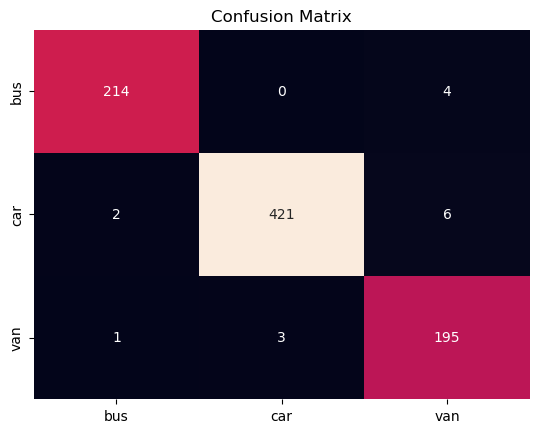

Classification Report for the training data
____________________________________________________________
              precision    recall  f1-score   support

         bus       0.99      0.98      0.98       218
         car       0.99      0.98      0.99       429
         van       0.95      0.98      0.97       199

    accuracy                           0.98       846
   macro avg       0.98      0.98      0.98       846
weighted avg       0.98      0.98      0.98       846



In [71]:
Performance_parameters(Model1_svm,X_scaled,y)

**C. Apply PCA on the data with 10 components**

In [72]:
pca1=PCA(n_components=10)
pca1.fit(X_scaled)

PCA(n_components=10)

In [73]:
pca1.explained_variance_

array([9.40828822, 3.01605477, 1.90347881, 1.18027268, 0.91717407,
       0.53927982, 0.35856646, 0.22166173, 0.16003619, 0.09171409])

In [74]:
pca1.explained_variance_ratio_

array([0.52206485, 0.16736054, 0.10562382, 0.0654932 , 0.05089389,
       0.02992458, 0.01989681, 0.01229998, 0.00888039, 0.0050892 ])

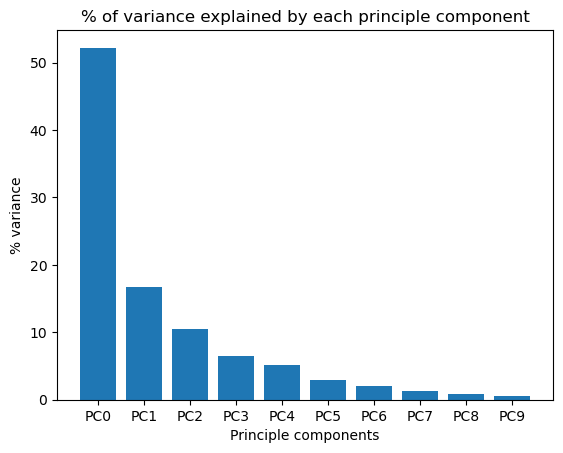

In [75]:
labels=["PC0","PC1","PC2","PC3","PC4","PC5","PC6","PC7","PC8","PC9"]
plt.bar(labels,pca1.explained_variance_ratio_*100,label=labels)
plt.title("% of variance explained by each principle component")
plt.xlabel("Principle components")
plt.ylabel("% variance")
plt.show()

**D. Visualize Cumulative Variance Explained with Number of Components.**

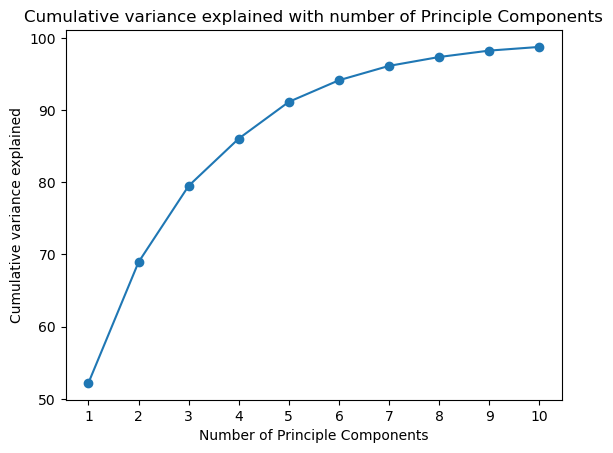

In [76]:
plt.plot(list(np.arange(1,11)),np.cumsum(pca1.explained_variance_ratio_*100),marker="o")
plt.xticks(list(np.arange(1,11)),label=list(np.arange(1,11)))
plt.title("Cumulative variance explained with number of Principle Components")
plt.xlabel("Number of Principle Components")
plt.ylabel("Cumulative variance explained")
plt.show()

**E. Draw a horizontal line on the above plot to highlight the threshold of 90%.**

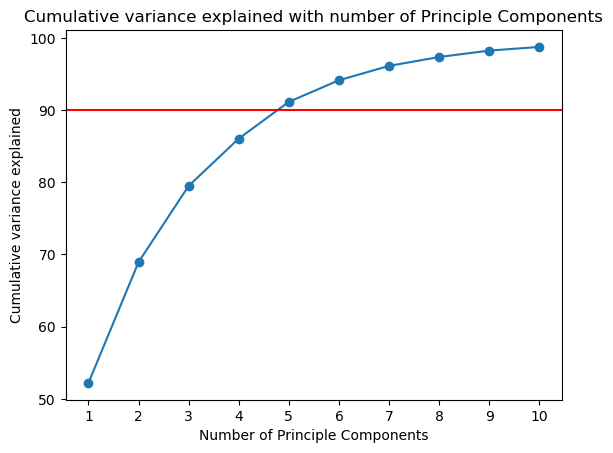

In [77]:
plt.plot(list(np.arange(1,11)),np.cumsum(pca1.explained_variance_ratio_*100),marker="o")
plt.xticks(list(np.arange(1,11)),label=list(np.arange(1,11)))
plt.title("Cumulative variance explained with number of Principle Components")
plt.axhline(y=90,color="red",linestyle="-")
plt.xlabel("Number of Principle Components")
plt.ylabel("Cumulative variance explained")
plt.show()

Insights from the plot:
- In the plot above we can see that 4 principle components explains less that 90% of the variance
- 5 principle components explains variance just above 90%

**F. Apply PCA on the data. This time Select Minimum Components with 90% or above variance explained.**

In [78]:
#When the number of PCA components is 5 the amount of variance explained is just above 90% 
#hence let us create a pca with n_components =5
pca2=PCA(n_components=5)
pca2.fit(X_scaled)

X_pca_transform2=pca2.transform(X_scaled)

In [79]:
X_pca2=pd.DataFrame(X_pca_transform2,columns=["PC0","PC1","PC2","PC3","PC4"],index=list(np.arange(0,846)))

In [80]:
X_pca2.head()

,PC0,PC1,PC2,PC3,PC4
0,0.332393,-0.218638,1.001286,0.177328,0.079106
1,-1.593741,-0.420549,-0.369264,0.233484,0.693397
2,3.767535,0.195041,0.088237,1.203129,0.730907
3,-1.740753,-2.829579,0.109176,0.377522,-0.363483
4,0.555239,4.757557,11.703588,0.145068,3.257651


**G. Train SVM model on components selected from above step.**

In [81]:
Model2_svm=SVC(random_state=1)
Model2_svm.fit(X_pca2,y)

SVC(random_state=1)

**H. Print Classification metrics for train data of above model and share insights.**

Accuracy score with the training data is:  0.806146572104019


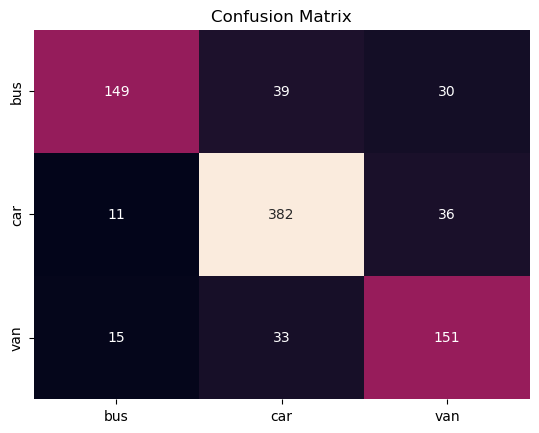

Classification Report for the training data
____________________________________________________________
              precision    recall  f1-score   support

         bus       0.85      0.68      0.76       218
         car       0.84      0.89      0.87       429
         van       0.70      0.76      0.73       199

    accuracy                           0.81       846
   macro avg       0.80      0.78      0.78       846
weighted avg       0.81      0.81      0.80       846



In [82]:
Performance_parameters(Model2_svm,X_pca2,y)

Comparing the performance for Model1 and Model2:
- The accuracy of the model trained with the PCA minimum components(n_components=5) has reduced
- Precision, recall and F1-score for all the 3 labels have reduced significantly for the model trained with the PCA minimum components
- Model with the actual independent variables has an accuracy of 98% which can also be attributed to overfitting in the model

The model that is formed with the % of variance explained with 5 pca components is not performing as good as the model that is formed with the actual components. Hence it is not very advisable for components reduction

### 4. Performance Improvement

**A. Train another SVM on the components out of PCA. Tune the parameters to improve performance.**

In [83]:
#PCA 1 has the the number of components =10. 
#Tranforming the actual X into the principle components with n_components=10

X_pca_transform1=pca1.transform(X_scaled)
X_pca1=pd.DataFrame(X_pca_transform1,columns=["PC0","PC1","PC2","PC3","PC4","PC5","PC6","PC7","PC8","PC9"],index=(np.arange(0,846)))

In [84]:
X_pca1

,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,0.332393,-0.218638,1.001286,0.177328,0.079106,-0.754814,-0.902187,-0.383358,-0.868964,0.088599
1,-1.593741,-0.420549,-0.369264,0.233484,0.693397,-0.519073,0.376234,0.247624,0.146542,-0.096104
2,3.767535,0.195041,0.088237,1.203129,0.730907,0.705377,-0.032642,0.483439,-0.308888,-0.469880
3,-1.740753,-2.829579,0.109176,0.377522,-0.363483,-0.487863,0.468613,-0.022129,-0.029270,0.458229
4,0.555239,4.757557,11.703588,0.145068,3.257651,-0.211649,2.671191,-0.446380,2.090488,-0.348406
...,...,...,...,...,...,...,...,...,...,...
841,-0.444331,-0.606954,0.197136,-1.444534,1.065525,0.819842,-0.040515,0.507866,-0.304760,-0.160331
842,-0.316589,0.164627,0.794183,-0.907933,-0.235175,-1.437506,-0.603595,-0.155295,-0.310103,0.199344
843,4.807810,-0.001824,0.532773,0.295988,-1.344737,-0.219630,0.572948,0.110918,-0.652654,0.554811
844,-3.295728,-1.008803,-0.357468,-1.933241,0.043075,-0.403457,-0.205109,0.319508,-0.201552,-0.875978


In [85]:
SVM_Param = {'C': [0.1,1, 10], 'gamma': [1,0.1,0.25,0.025],'kernel':['linear', 'poly', 'rbf', 'sigmoid']}
grid = GridSearchCV(SVC(),SVM_Param,refit=True,verbose=2)
SVM_Modeltune=grid.fit(X_pca1,y)


print("The value of best Hyperparameters")
print('Best C :', SVM_Modeltune.best_estimator_.get_params()['C'])
print('Best gamma :', SVM_Modeltune.best_estimator_.get_params()['gamma'])
print('Best kernel :',SVM_Modeltune.best_estimator_.get_params()['kernel'])

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=

[CV] END ........................C=1, gamma=0.1, kernel=poly; total time=   0.0s
[CV] END ........................C=1, gamma=0.1, kernel=poly; total time=   0.0s
[CV] END ........................C=1, gamma=0.1, kernel=poly; total time=   0.0s
[CV] END ........................C=1, gamma=0.1, kernel=poly; total time=   0.0s
[CV] END ........................C=1, gamma=0.1, kernel=poly; total time=   0.0s
[CV] END .........................C=1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .........................C=1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .........................C=1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .........................C=1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .........................C=1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .....................C=1, gamma=0.1, kernel=sigmoid; total time=   0.0s
[CV] END .....................C=1, gamma=0.1, kernel=sigmoid; total time=   0.0s
[CV] END ...................

[CV] END .......................C=10, gamma=0.25, kernel=rbf; total time=   0.0s
[CV] END .......................C=10, gamma=0.25, kernel=rbf; total time=   0.0s
[CV] END .......................C=10, gamma=0.25, kernel=rbf; total time=   0.0s
[CV] END .......................C=10, gamma=0.25, kernel=rbf; total time=   0.0s
[CV] END .......................C=10, gamma=0.25, kernel=rbf; total time=   0.0s
[CV] END ...................C=10, gamma=0.25, kernel=sigmoid; total time=   0.0s
[CV] END ...................C=10, gamma=0.25, kernel=sigmoid; total time=   0.0s
[CV] END ...................C=10, gamma=0.25, kernel=sigmoid; total time=   0.0s
[CV] END ...................C=10, gamma=0.25, kernel=sigmoid; total time=   0.0s
[CV] END ...................C=10, gamma=0.25, kernel=sigmoid; total time=   0.0s
[CV] END ...................C=10, gamma=0.025, kernel=linear; total time=   0.0s
[CV] END ...................C=10, gamma=0.025, kernel=linear; total time=   0.0s
[CV] END ...................

**B. Share best Parameters observed from above step.**

In [86]:
print("The value of best Hyperparameters")
print('Best C :', SVM_Modeltune.best_estimator_.get_params()['C'])
print('Best gamma :', SVM_Modeltune.best_estimator_.get_params()['gamma'])
print('Best kernel :',SVM_Modeltune.best_estimator_.get_params()['kernel'])

The value of best Hyperparameters
Best C : 10
Best gamma : 0.1
Best kernel : rbf


In [87]:
Model3_svm=SVC(C=10,gamma=0.1,kernel='rbf',random_state=1)
Model3_svm.fit(X_pca1,y)

SVC(C=10, gamma=0.1, random_state=1)

**C. Print Classification metrics for train data of above model and share relative improvement in performance in all the models along with insights.**

Accuracy score with the training data is:  0.9940898345153665


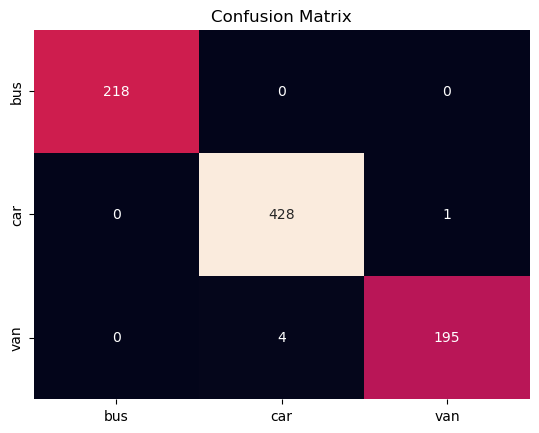

Classification Report for the training data
____________________________________________________________
              precision    recall  f1-score   support

         bus       1.00      1.00      1.00       218
         car       0.99      1.00      0.99       429
         van       0.99      0.98      0.99       199

    accuracy                           0.99       846
   macro avg       1.00      0.99      0.99       846
weighted avg       0.99      0.99      0.99       846



In [88]:
Performance_parameters(Model3_svm,X_pca1,y)

Model1 - SVC with the actual x variables <br>
Model2 - SVC with the x variables represented by 5 principle components <br>
Model3 - SVC with x variables represented by 10 principle components<br>

- Model3 has the highest accuracy among the 3 models with an accuracy as high as 99%
- Representing the actual x variables with 5 principle components had some information loss because the training data accuracy reduced from 98 to 81%
- There was a reduction in performances wrt the precision, recall and F1-score for all the 3 labels for Model 2
- There was a considerable improvement in the performances when comparing the models with 5 principle components and 10 principle components

We can conclude that the data represented by 10 principle components has a better performance among the 3 models.

### 5. Data Understanding & Cleaning

**A. Explain pre-requisite/assumptions of PCA.**

Pre-requisites for PCA:

- Ensure that there are no missing values in the dataset
- The dataset needs to be scaled since PCA is sensitive to the scales
- PCA is a technique used to represent the independent variables in the dataset hence the presence of outliers in the dataset will affect the PCA when representing the data. In short, we can say that PCA is affected by outliers
- PCA assumes that the features have a linear relationship
- Dataset should be some correlation between the features in the dataset only then they can be better represented by lesser number of features

**B. Explain advantages and limitations of PCA.**

Advantages of PCA:
- Reducing the features in the dataset helps in reducing the model complexity
- Reduction in the features helps in getting a better model training time
- By reducing the dimensions we inturn removes the multi collinearity and hence a reduction in the noise that was present in the actual dataset
- When there are too many variables in the dataset using PCA to reduce dimensions will help in reducing the overfit
- 

Disadvantages/limitations of PCA:
- The main disadvantage is that the interpretability of the dataset is lost after transforming the features into principle components
- Though there is a reduction in noise from the original dataset, it is very likely that this might come with a loss in information as well
- PCA gets affected by outliers, the variance in the dataset because of the outliers will also be captured in PCA
- PCA gets affected if the features are in different scales so it is required that the features be scaled before applying PCA